## Imports and Setup

In [17]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger

from src import (
    TREATMENTS, N_TREATMENTS, IDX_TO_TREATMENT, TREATMENT_TO_IDX,
    CONTEXT_FEATURES, reward_oracle,
)
from src.utils import setup_plotting, seed_everything, TREATMENT_COLORS

seed_everything(42)
setup_plotting()
print("Setup complete")

2026-04-16 00:34:39.114 | INFO     | src.utils:seed_everything:428 - Seeds set to 42


Setup complete


## Load Dataset

In [18]:
df = pd.read_csv("../data/bandit_dataset.csv")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()


Dataset shape: (20000, 31)
Columns: ['patient_id', 'age', 'bmi', 'hba1c_baseline', 'egfr', 'diabetes_duration', 'fasting_glucose', 'c_peptide', 'cvd', 'ckd', 'nafld', 'hypertension', 'bp_systolic', 'ldl', 'hdl', 'triglycerides', 'alt', 'action', 'action_name', 'reward', 'propensity', 'propensity_all', 'reward_0', 'reward_1', 'reward_2', 'reward_3', 'reward_4', 'optimal_action', 'optimal_action_name', 'optimal_reward', 'regret']


,patient_id,age,bmi,hba1c_baseline,egfr,diabetes_duration,fasting_glucose,c_peptide,cvd,ckd,...,propensity_all,reward_0,reward_1,reward_2,reward_3,reward_4,optimal_action,optimal_action_name,optimal_reward,regret
0,P000001,63,36.8,7.49,92.6,2.6,171.2,1.93,1,0,...,"[0.3699, 0.265, 0.265, 0.0501, 0.0501]",1.143,0.893,1.593,0.718,0.000,2,SGLT-2,1.593,0.700
1,P000002,52,30.9,11.18,88.3,11.7,245.4,0.81,1,1,...,"[0.0638, 0.0638, 0.3376, 0.0638, 0.4711]",0.957,0.000,2.032,0.057,1.032,2,SGLT-2,2.032,2.032
2,P000003,51,41.0,9.90,69.0,11.4,211.5,1.44,0,1,...,"[0.1076, 0.5696, 0.1076, 0.1076, 0.1076]",0.734,1.859,1.059,0.634,0.234,1,GLP-1,1.859,0.000
3,P000004,44,37.2,7.87,109.8,12.7,168.1,1.56,1,0,...,"[0.3699, 0.265, 0.265, 0.0501, 0.0501]",0.408,1.408,1.608,0.000,0.000,2,SGLT-2,1.608,0.000
4,P000005,68,32.4,9.14,70.3,13.2,253.4,0.82,0,1,...,"[0.1076, 0.1076, 0.1076, 0.5696, 0.1076]",0.080,0.330,0.955,1.730,0.455,3,DPP-4,1.730,0.000


## Basic Dataset Info

In [19]:
print(f"Total patients: {len(df):,}")
print(f"Features: {len(CONTEXT_FEATURES)}")
print(f"Treatments: {N_TREATMENTS}")
print(f"\nColumn dtypes:")
print(df.dtypes.value_counts())
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.describe().round(3)

Total patients: 20,000
Features: 16
Treatments: 5

Column dtypes:
float64    20
int64       7
str         4
Name: count, dtype: int64

Missing values: 0


,age,bmi,hba1c_baseline,egfr,diabetes_duration,fasting_glucose,c_peptide,cvd,ckd,nafld,...,reward,propensity,reward_0,reward_1,reward_2,reward_3,reward_4,optimal_action,optimal_reward,regret
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,...,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,57.486,33.689,8.903,89.168,9.082,179.399,1.308,0.346,0.168,0.460,...,0.957,0.355,0.864,0.611,0.675,0.616,0.326,1.517,1.508,0.552
std,11.865,5.237,1.362,20.563,7.092,43.114,0.440,0.476,0.374,0.498,...,0.660,0.199,0.565,0.643,0.773,0.631,0.510,1.309,0.322,0.616
min,25.000,22.000,6.550,15.000,0.000,80.000,0.100,0.000,0.000,0.000,...,0.000,0.041,0.000,0.000,0.000,0.000,0.000,0.000,0.347,0.000
25%,49.000,30.000,7.890,75.200,3.700,148.800,1.020,0.000,0.000,0.000,...,0.338,0.200,0.396,0.000,0.000,0.000,0.000,0.000,1.262,0.000
50%,58.000,33.600,8.650,89.300,7.200,174.100,1.320,0.000,0.000,0.000,...,1.037,0.338,0.808,0.321,0.000,0.459,0.044,2.000,1.599,0.275
75%,65.000,37.825,9.650,103.500,12.800,205.100,1.610,1.000,0.000,1.000,...,1.571,0.471,1.323,1.172,1.572,1.187,0.457,3.000,1.677,1.068
max,85.000,45.000,14.000,130.000,30.000,350.000,2.950,1.000,1.000,1.000,...,2.846,0.649,1.700,1.950,2.150,2.262,2.575,4.000,2.575,2.575


## Treatment (Action) Distribution from Logging Policy

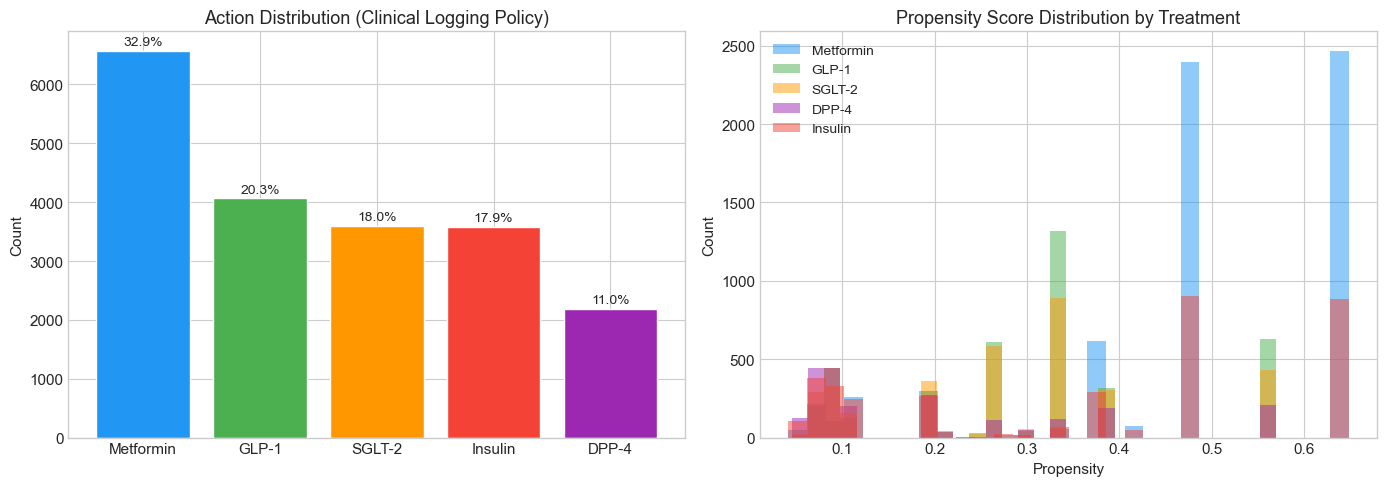


Action distribution:
action_name
Metformin    6574
GLP-1        4063
SGLT-2       3599
Insulin      3572
DPP-4        2192

Propensity stats:
              count    mean     std     min     25%     50%     75%     max
action_name                                                                
DPP-4        2192.0  0.1976  0.1609  0.0453  0.0736  0.1076  0.2961  0.5696
GLP-1        4063.0  0.3055  0.1493  0.0453  0.2000  0.3376  0.3376  0.5696
Insulin      3572.0  0.3647  0.2219  0.0412  0.1076  0.4711  0.4711  0.6488
Metformin    6574.0  0.4765  0.1752  0.0412  0.4156  0.4711  0.6488  0.6488
SGLT-2       3599.0  0.2770  0.1501  0.0453  0.1076  0.2650  0.3376  0.5696


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
action_counts = df['action_name'].value_counts()
colors = [TREATMENT_COLORS[t] for t in action_counts.index]
ax1.bar(action_counts.index, action_counts.values, color=colors, edgecolor='white')
ax1.set_title("Action Distribution (Clinical Logging Policy)")
ax1.set_ylabel("Count")
for i, (name, count) in enumerate(action_counts.items()):
    ax1.text(i, count + 100, f"{count/len(df)*100:.1f}%", ha='center', fontsize=10)

# Propensity distribution per treatment
for t in TREATMENTS:
    mask = df['action_name'] == t
    ax2.hist(df.loc[mask, 'propensity'], bins=30, alpha=0.5,
             label=t, color=TREATMENT_COLORS[t])
ax2.set_title("Propensity Score Distribution by Treatment")
ax2.set_xlabel("Propensity")
ax2.set_ylabel("Count")
ax2.legend()

plt.tight_layout()
plt.show()

print("\nAction distribution:")
print(df['action_name'].value_counts().to_string())
print(f"\nPropensity stats:")
print(df.groupby('action_name')['propensity'].describe().round(4))

## Context Feature Distributions

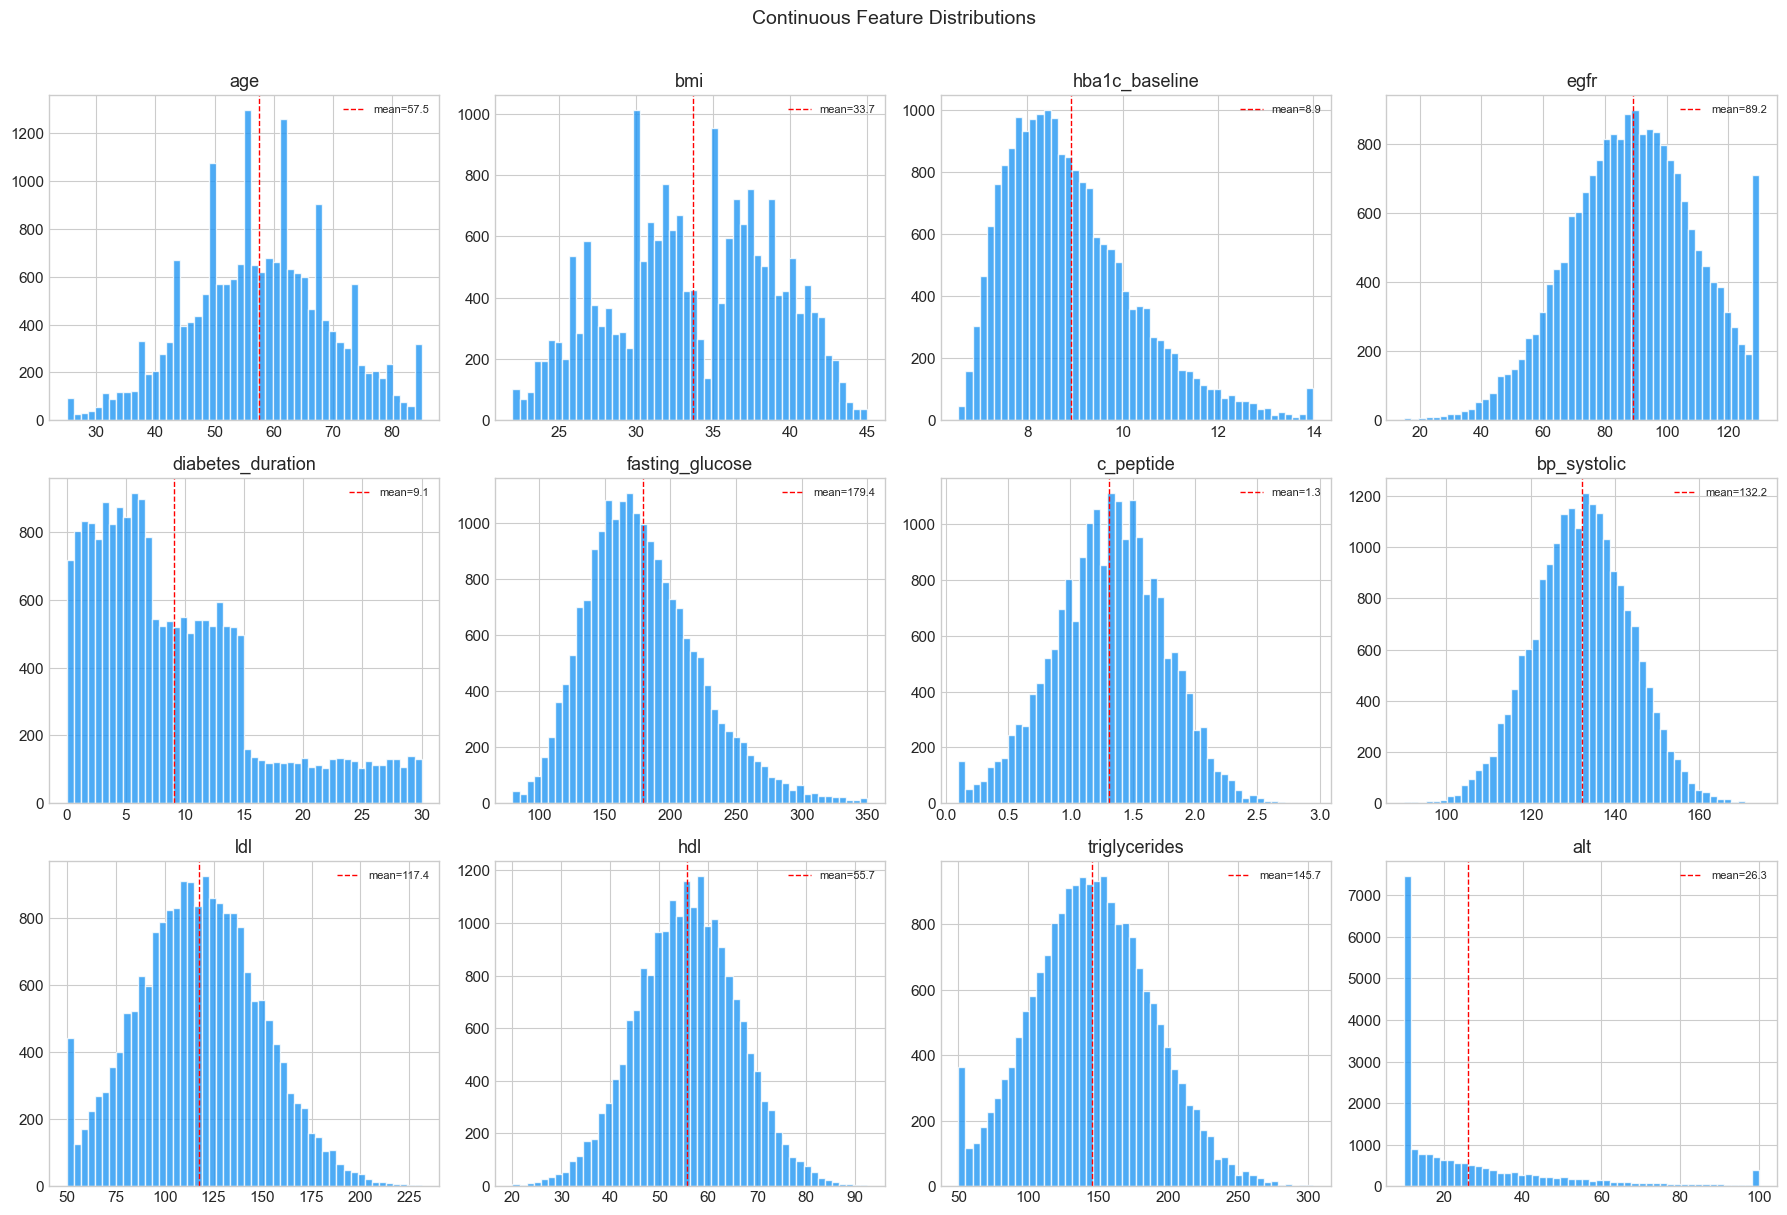

In [21]:
continuous_feats = ['age', 'bmi', 'hba1c_baseline', 'egfr', 'diabetes_duration',
                    'fasting_glucose', 'c_peptide', 'bp_systolic', 'ldl', 'hdl',
                    'triglycerides', 'alt']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(continuous_feats):
    ax = axes[i]
    ax.hist(df[feat], bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
    ax.set_title(feat)
    ax.axvline(df[feat].mean(), color='red', linestyle='--', linewidth=1, label=f'mean={df[feat].mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle("Continuous Feature Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Binary Feature Distributions

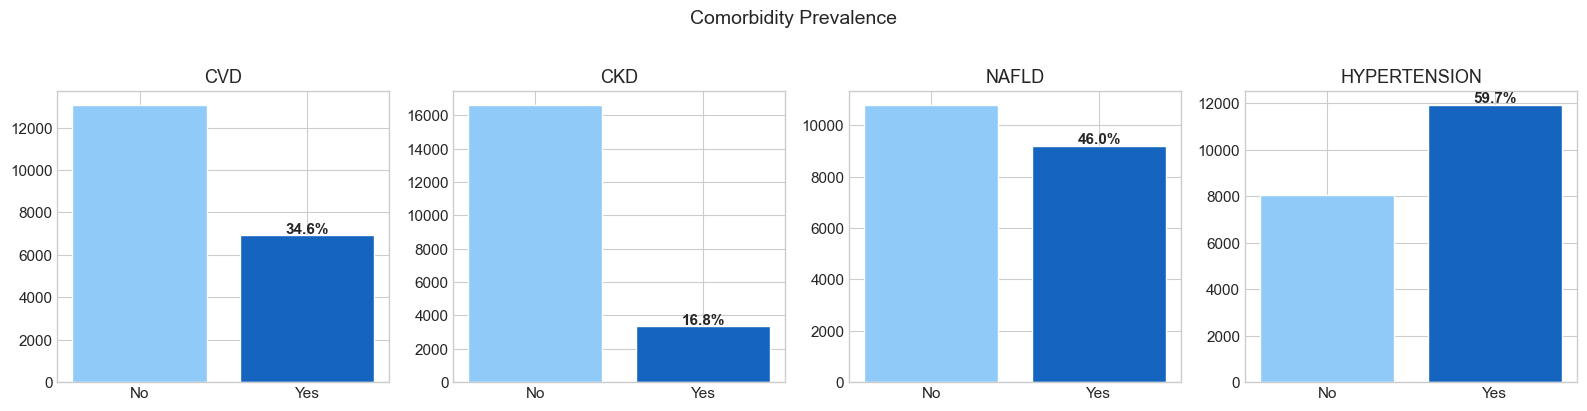

In [22]:
binary_feats = ['cvd', 'ckd', 'nafld', 'hypertension']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, feat in enumerate(binary_feats):
    ax = axes[i]
    counts = df[feat].value_counts().sort_index()
    ax.bar(['No', 'Yes'], counts.values, color=['#90CAF9', '#1565C0'], edgecolor='white')
    ax.set_title(feat.upper())
    pct = df[feat].mean() * 100
    ax.text(1, counts.values[1] + 100, f"{pct:.1f}%", ha='center', fontsize=11, fontweight='bold')

plt.suptitle("Comorbidity Prevalence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Feature Correlation Matrix

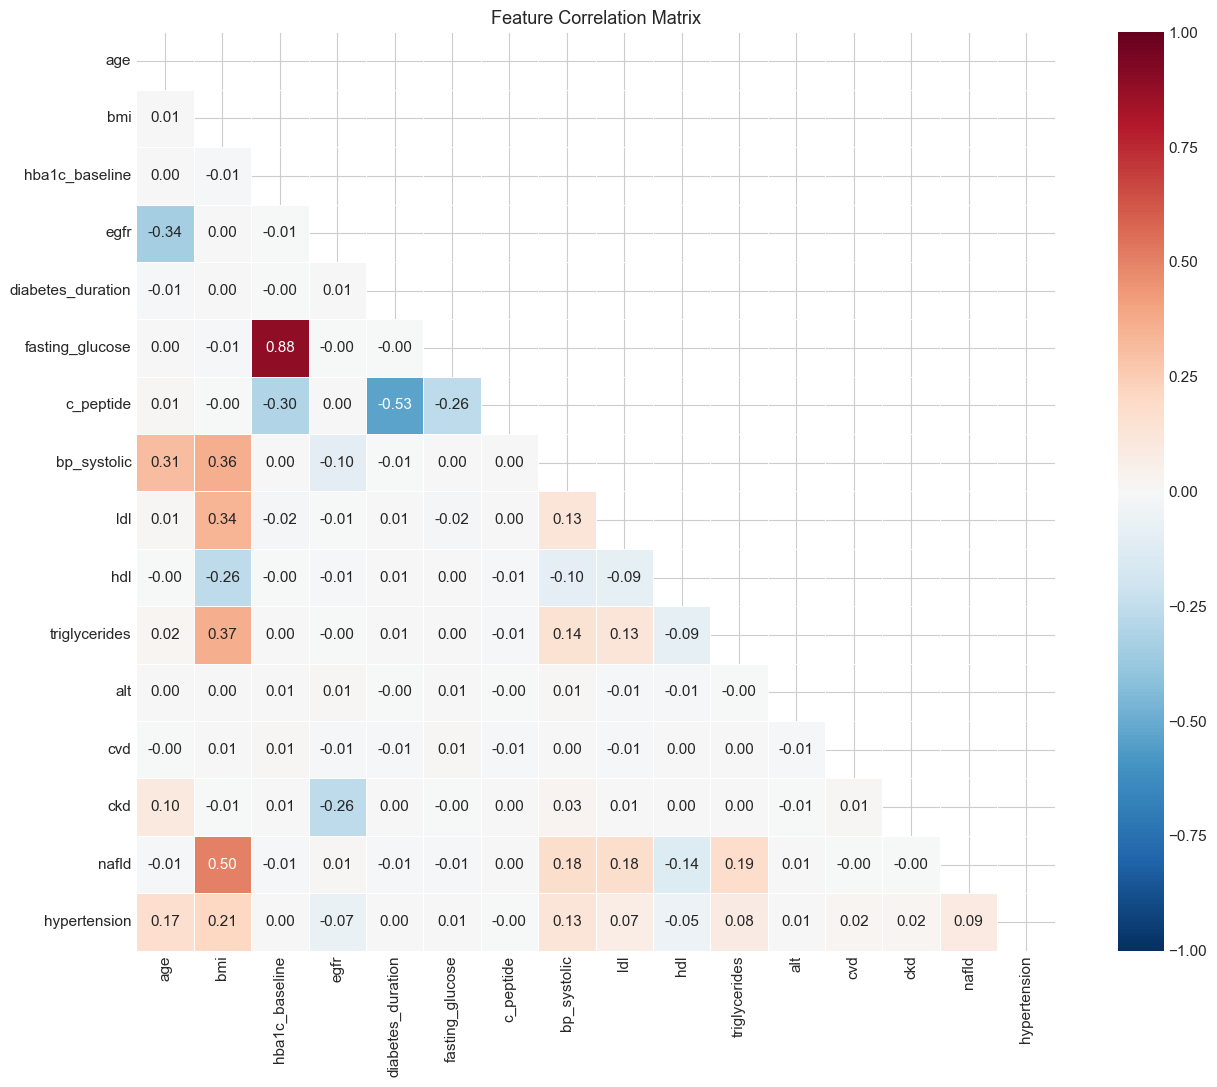

Strong correlations (|r| > 0.5):
  hba1c_baseline       ↔ fasting_glucose      r=0.885
  diabetes_duration    ↔ c_peptide            r=-0.532
  bmi                  ↔ nafld                r=0.503


In [23]:
fig, ax = plt.subplots(figsize=(14, 11))
feat_cols = continuous_feats + binary_feats
corr = df[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Flag strong correlations
strong = []
for i in range(len(feat_cols)):
    for j in range(i+1, len(feat_cols)):
        r = abs(corr.iloc[i, j])
        if r > 0.5:
            strong.append((feat_cols[i], feat_cols[j], round(corr.iloc[i, j], 3)))
print("Strong correlations (|r| > 0.5):")
for a, b, r in sorted(strong, key=lambda x: -abs(x[2])):
    print(f"  {a:<20} ↔ {b:<20} r={r}")

## Reward Distribution (Observed)

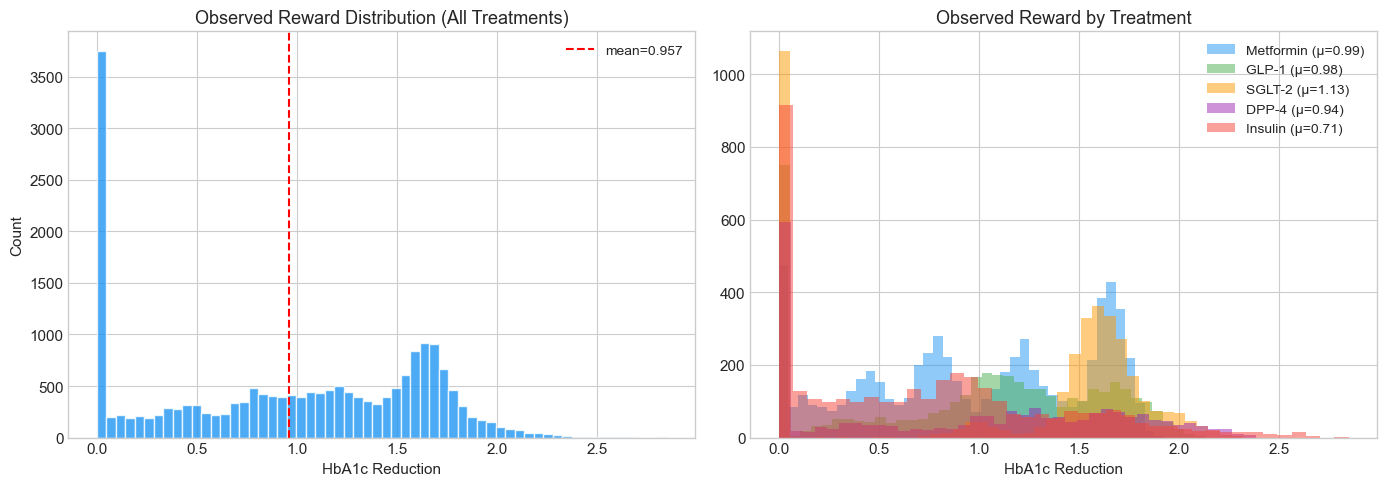

Observed reward stats by treatment:
              count   mean    std  min    25%    50%    75%    max
action_name                                                       
DPP-4        2192.0  0.937  0.746  0.0  0.000  1.050  1.602  2.384
GLP-1        4063.0  0.978  0.618  0.0  0.464  1.081  1.486  2.132
Insulin      3572.0  0.713  0.648  0.0  0.057  0.657  1.091  2.846
Metformin    6574.0  0.992  0.557  0.0  0.533  1.048  1.561  1.924
SGLT-2       3599.0  1.127  0.762  0.0  0.000  1.524  1.672  2.320


In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall reward distribution
ax1.hist(df['reward'], bins=60, color='#2196F3', edgecolor='white', alpha=0.8)
ax1.axvline(df['reward'].mean(), color='red', linestyle='--', label=f"mean={df['reward'].mean():.3f}")
ax1.set_title("Observed Reward Distribution (All Treatments)")
ax1.set_xlabel("HbA1c Reduction")
ax1.set_ylabel("Count")
ax1.legend()

# Per-treatment reward
for t in TREATMENTS:
    mask = df['action_name'] == t
    ax2.hist(df.loc[mask, 'reward'], bins=40, alpha=0.5,
             label=f"{t} (μ={df.loc[mask, 'reward'].mean():.2f})",
             color=TREATMENT_COLORS[t])
ax2.set_title("Observed Reward by Treatment")
ax2.set_xlabel("HbA1c Reduction")
ax2.legend()

plt.tight_layout()
plt.show()

print("Observed reward stats by treatment:")
print(df.groupby('action_name')['reward'].describe().round(3))

## Counterfactual Reward Analysis (Ground Truth)

Counterfactual (expected) reward by treatment:
       Metformin      GLP-1     SGLT-2      DPP-4    Insulin
count  20000.000  20000.000  20000.000  20000.000  20000.000
mean       0.864      0.611      0.675      0.616      0.326
std        0.565      0.643      0.773      0.631      0.510
min        0.000      0.000      0.000      0.000      0.000
25%        0.396      0.000      0.000      0.000      0.000
50%        0.808      0.321      0.000      0.459      0.044
75%        1.323      1.172      1.572      1.187      0.457
max        1.700      1.950      2.150      2.262      2.575


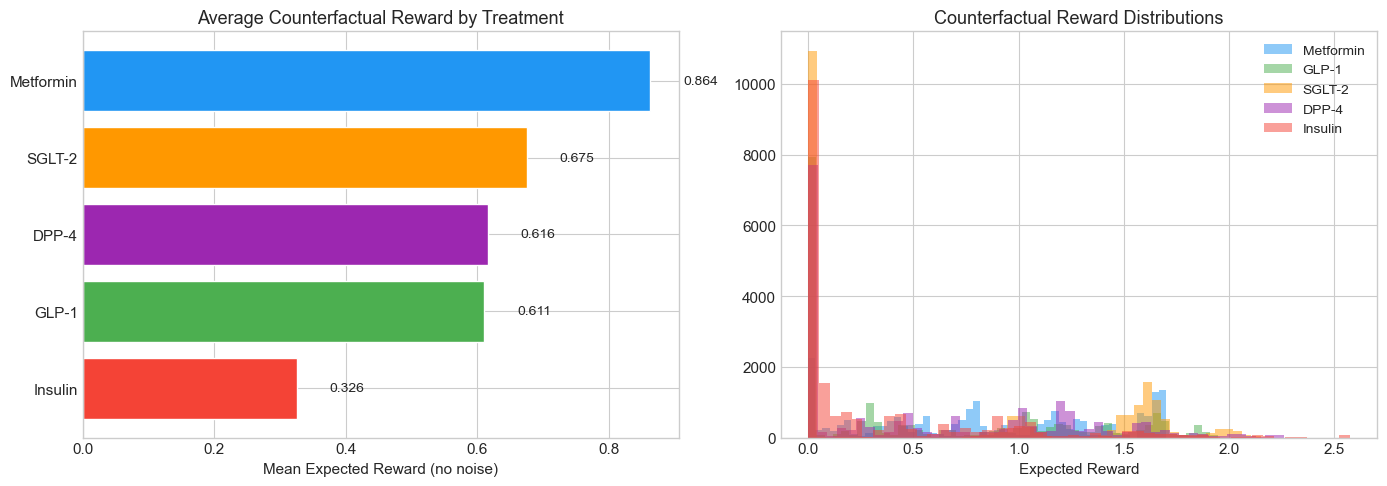

In [25]:
reward_cols = [f'reward_{i}' for i in range(N_TREATMENTS)]
cf = df[reward_cols]
cf.columns = TREATMENTS

print("Counterfactual (expected) reward by treatment:")
print(cf.describe().round(3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mean counterfactual rewards
means = cf.mean().sort_values(ascending=True)
colors = [TREATMENT_COLORS[t] for t in means.index]
ax1.barh(means.index, means.values, color=colors, edgecolor='white')
ax1.set_xlabel("Mean Expected Reward (no noise)")
ax1.set_title("Average Counterfactual Reward by Treatment")
for i, (t, v) in enumerate(means.items()):
    ax1.text(v + 0.05, i, f"{v:.3f}", va='center', fontsize=10)

# Distribution of counterfactual rewards
for t in TREATMENTS:
    ax2.hist(cf[t], bins=50, alpha=0.5, label=t, color=TREATMENT_COLORS[t])
ax2.set_title("Counterfactual Reward Distributions")
ax2.set_xlabel("Expected Reward")
ax2.legend()

plt.tight_layout()
plt.show()

## Optimal Action Distribution (Oracle)

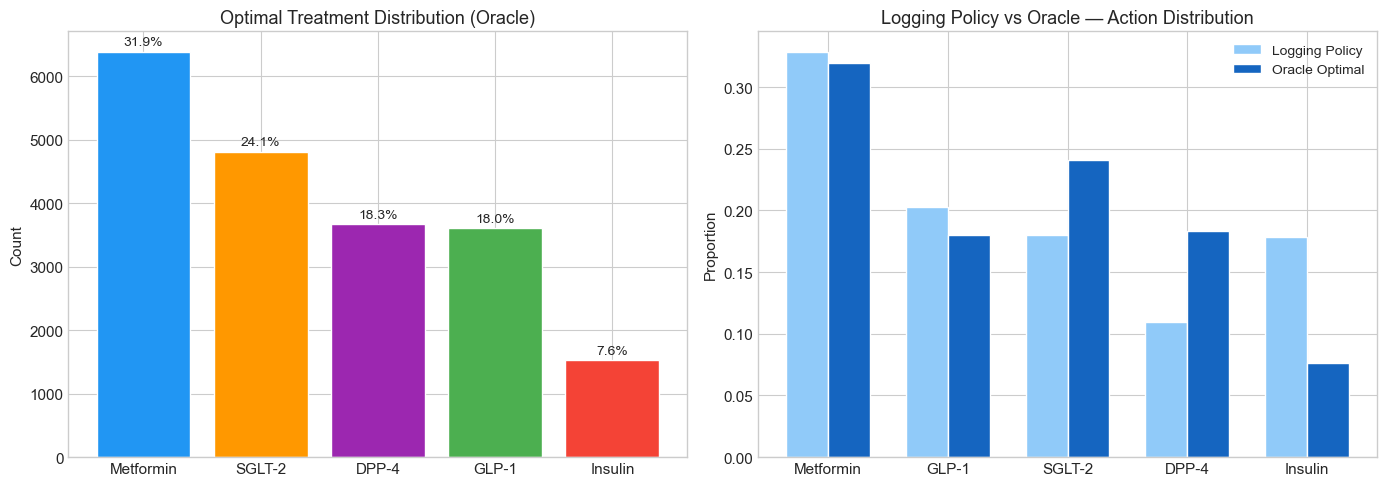

Logging policy accuracy (matches oracle): 0.3669 (36.7%)


In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Optimal action counts
opt_counts = df['optimal_action_name'].value_counts()
colors = [TREATMENT_COLORS[t] for t in opt_counts.index]
ax1.bar(opt_counts.index, opt_counts.values, color=colors, edgecolor='white')
ax1.set_title("Optimal Treatment Distribution (Oracle)")
ax1.set_ylabel("Count")
for i, (name, count) in enumerate(opt_counts.items()):
    ax1.text(i, count + 100, f"{count/len(df)*100:.1f}%", ha='center', fontsize=10)

# Logging policy vs oracle comparison
log_dist = df['action_name'].value_counts(normalize=True).reindex(TREATMENTS).fillna(0)
opt_dist = df['optimal_action_name'].value_counts(normalize=True).reindex(TREATMENTS).fillna(0)

x = np.arange(N_TREATMENTS)
w = 0.35
ax2.bar(x - w/2, log_dist.values, w, label='Logging Policy', color='#90CAF9', edgecolor='white')
ax2.bar(x + w/2, opt_dist.values, w, label='Oracle Optimal', color='#1565C0', edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(TREATMENTS)
ax2.set_ylabel("Proportion")
ax2.set_title("Logging Policy vs Oracle — Action Distribution")
ax2.legend()

plt.tight_layout()
plt.show()

# Accuracy of logging policy
accuracy = (df['action'] == df['optimal_action']).mean()
print(f"Logging policy accuracy (matches oracle): {accuracy:.4f} ({accuracy*100:.1f}%)")


## Regret Analysis

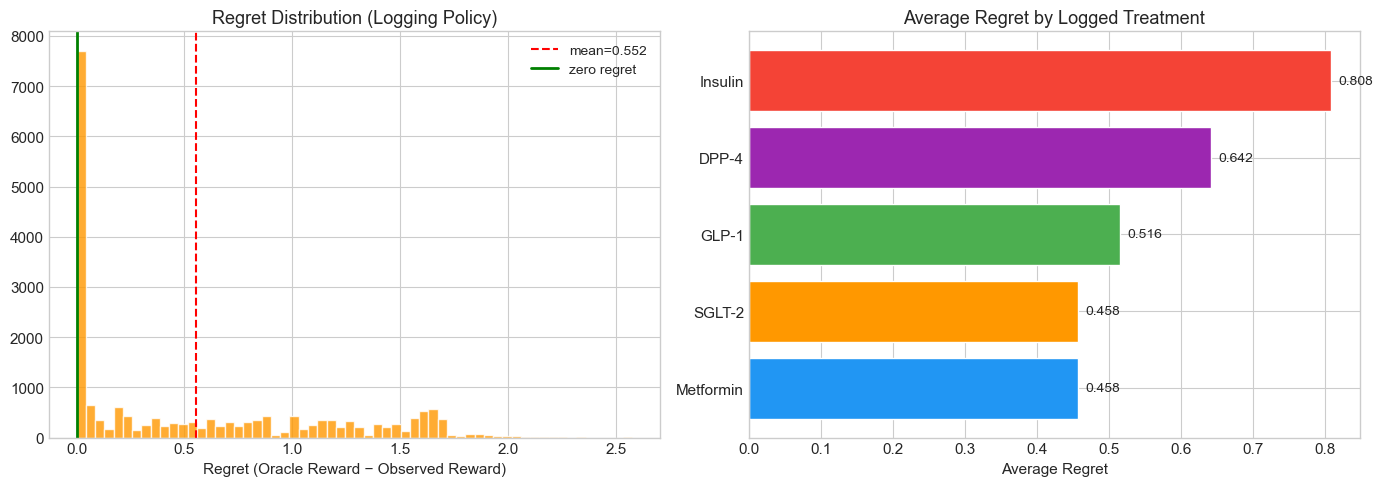

Overall mean regret: 0.5524
Zero-regret (correct) decisions: 7474 (37.4%)


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Regret distribution
ax1.hist(df['regret'], bins=60, color='#FF9800', edgecolor='white', alpha=0.8)
ax1.axvline(df['regret'].mean(), color='red', linestyle='--',
            label=f"mean={df['regret'].mean():.3f}")
ax1.axvline(0, color='green', linestyle='-', linewidth=2, label='zero regret')
ax1.set_title("Regret Distribution (Logging Policy)")
ax1.set_xlabel("Regret (Oracle Reward − Observed Reward)")
ax1.legend()

# Regret by logged treatment
regret_by_treatment = df.groupby('action_name')['regret'].mean().sort_values()
colors = [TREATMENT_COLORS[t] for t in regret_by_treatment.index]
ax2.barh(regret_by_treatment.index, regret_by_treatment.values, color=colors, edgecolor='white')
ax2.set_xlabel("Average Regret")
ax2.set_title("Average Regret by Logged Treatment")
for i, (t, v) in enumerate(regret_by_treatment.items()):
    ax2.text(v + 0.01, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Overall mean regret: {df['regret'].mean():.4f}")
print(f"Zero-regret (correct) decisions: {(df['regret'] == 0).sum()} ({(df['regret'] == 0).mean()*100:.1f}%)")


## Treatment-Context Relationships (Key Clinical Signals)

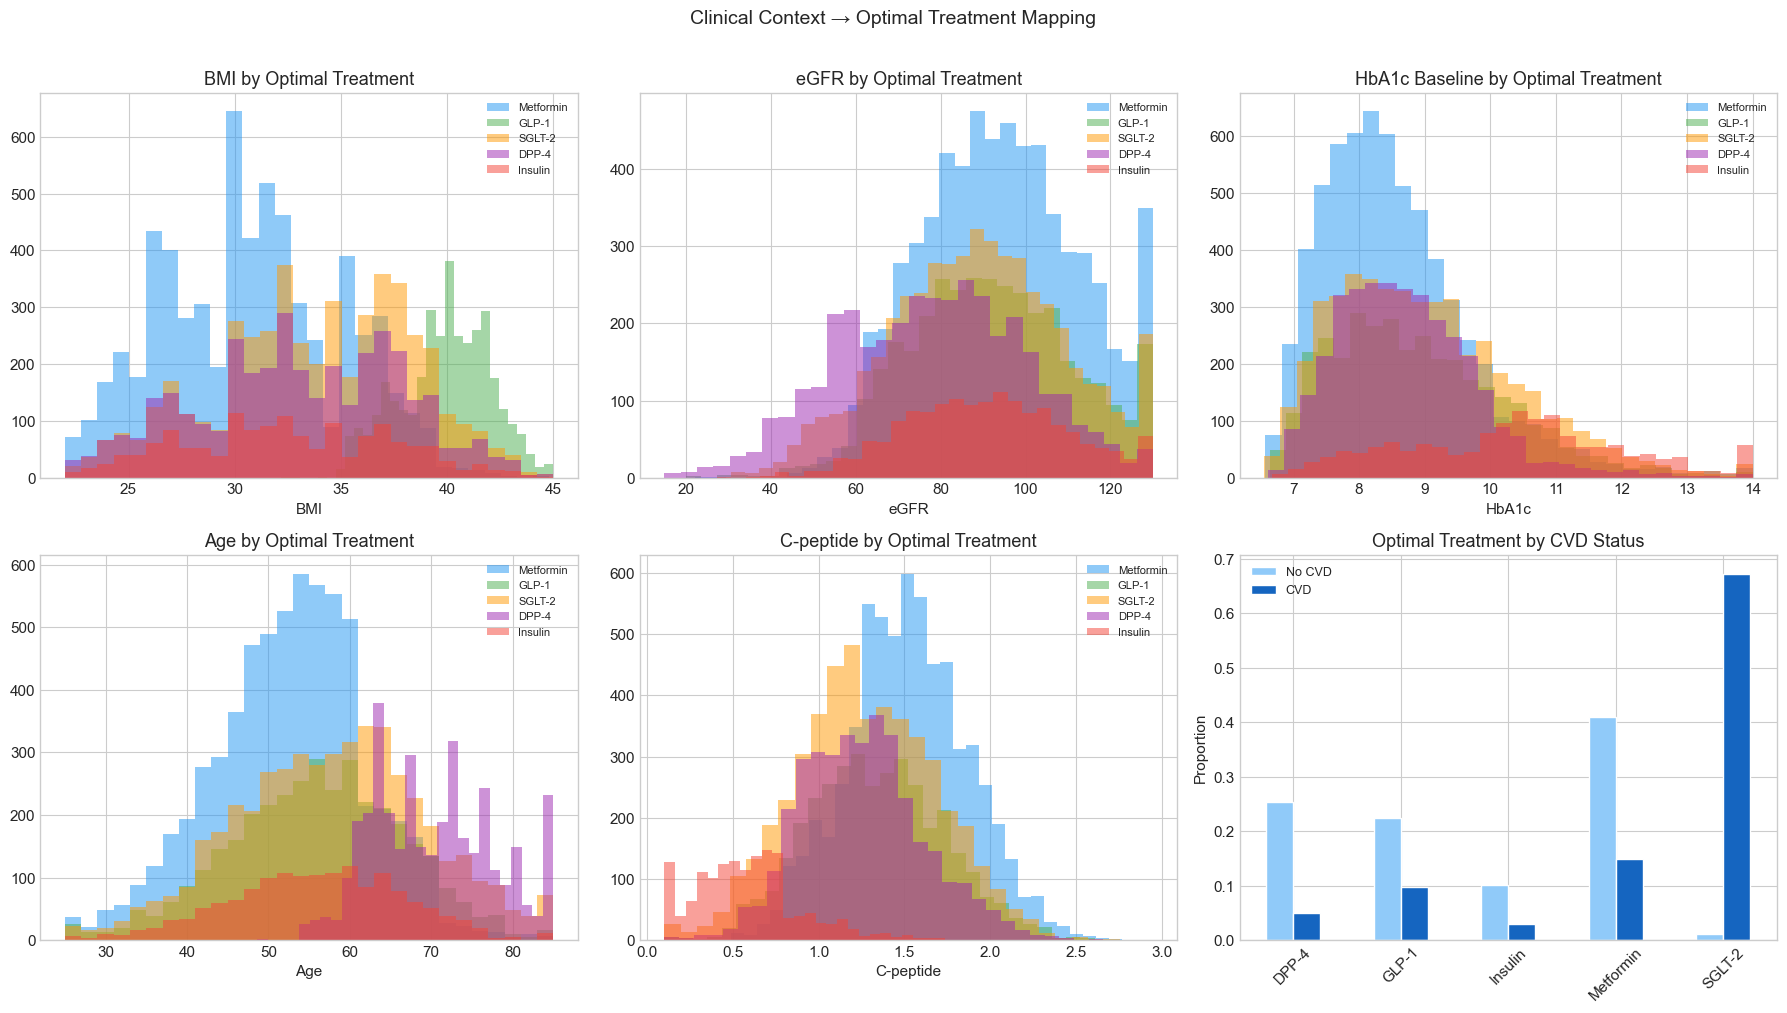

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. BMI vs optimal treatment
ax = axes[0, 0]
for t in TREATMENTS:
    mask = df['optimal_action_name'] == t
    ax.hist(df.loc[mask, 'bmi'], bins=30, alpha=0.5, label=t, color=TREATMENT_COLORS[t])
ax.set_title("BMI by Optimal Treatment")
ax.set_xlabel("BMI")
ax.legend(fontsize=8)

# 2. eGFR vs optimal treatment
ax = axes[0, 1]
for t in TREATMENTS:
    mask = df['optimal_action_name'] == t
    ax.hist(df.loc[mask, 'egfr'], bins=30, alpha=0.5, label=t, color=TREATMENT_COLORS[t])
ax.set_title("eGFR by Optimal Treatment")
ax.set_xlabel("eGFR")
ax.legend(fontsize=8)

# 3. HbA1c baseline vs optimal treatment
ax = axes[0, 2]
for t in TREATMENTS:
    mask = df['optimal_action_name'] == t
    ax.hist(df.loc[mask, 'hba1c_baseline'], bins=30, alpha=0.5, label=t, color=TREATMENT_COLORS[t])
ax.set_title("HbA1c Baseline by Optimal Treatment")
ax.set_xlabel("HbA1c")
ax.legend(fontsize=8)

# 4. Age vs optimal treatment
ax = axes[1, 0]
for t in TREATMENTS:
    mask = df['optimal_action_name'] == t
    ax.hist(df.loc[mask, 'age'], bins=30, alpha=0.5, label=t, color=TREATMENT_COLORS[t])
ax.set_title("Age by Optimal Treatment")
ax.set_xlabel("Age")
ax.legend(fontsize=8)

# 5. C-peptide vs optimal treatment
ax = axes[1, 1]
for t in TREATMENTS:
    mask = df['optimal_action_name'] == t
    ax.hist(df.loc[mask, 'c_peptide'], bins=30, alpha=0.5, label=t, color=TREATMENT_COLORS[t])
ax.set_title("C-peptide by Optimal Treatment")
ax.set_xlabel("C-peptide")
ax.legend(fontsize=8)

# 6. CVD presence vs optimal treatment
ax = axes[1, 2]
cross = pd.crosstab(df['optimal_action_name'], df['cvd'], normalize='columns')
cross.plot(kind='bar', ax=ax, color=['#90CAF9', '#1565C0'], edgecolor='white')
ax.set_title("Optimal Treatment by CVD Status")
ax.set_ylabel("Proportion")
ax.set_xlabel("")
ax.legend(['No CVD', 'CVD'], fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.suptitle("Clinical Context → Optimal Treatment Mapping", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Counterfactual Reward Heatmap (Treatment × Context Subgroups)

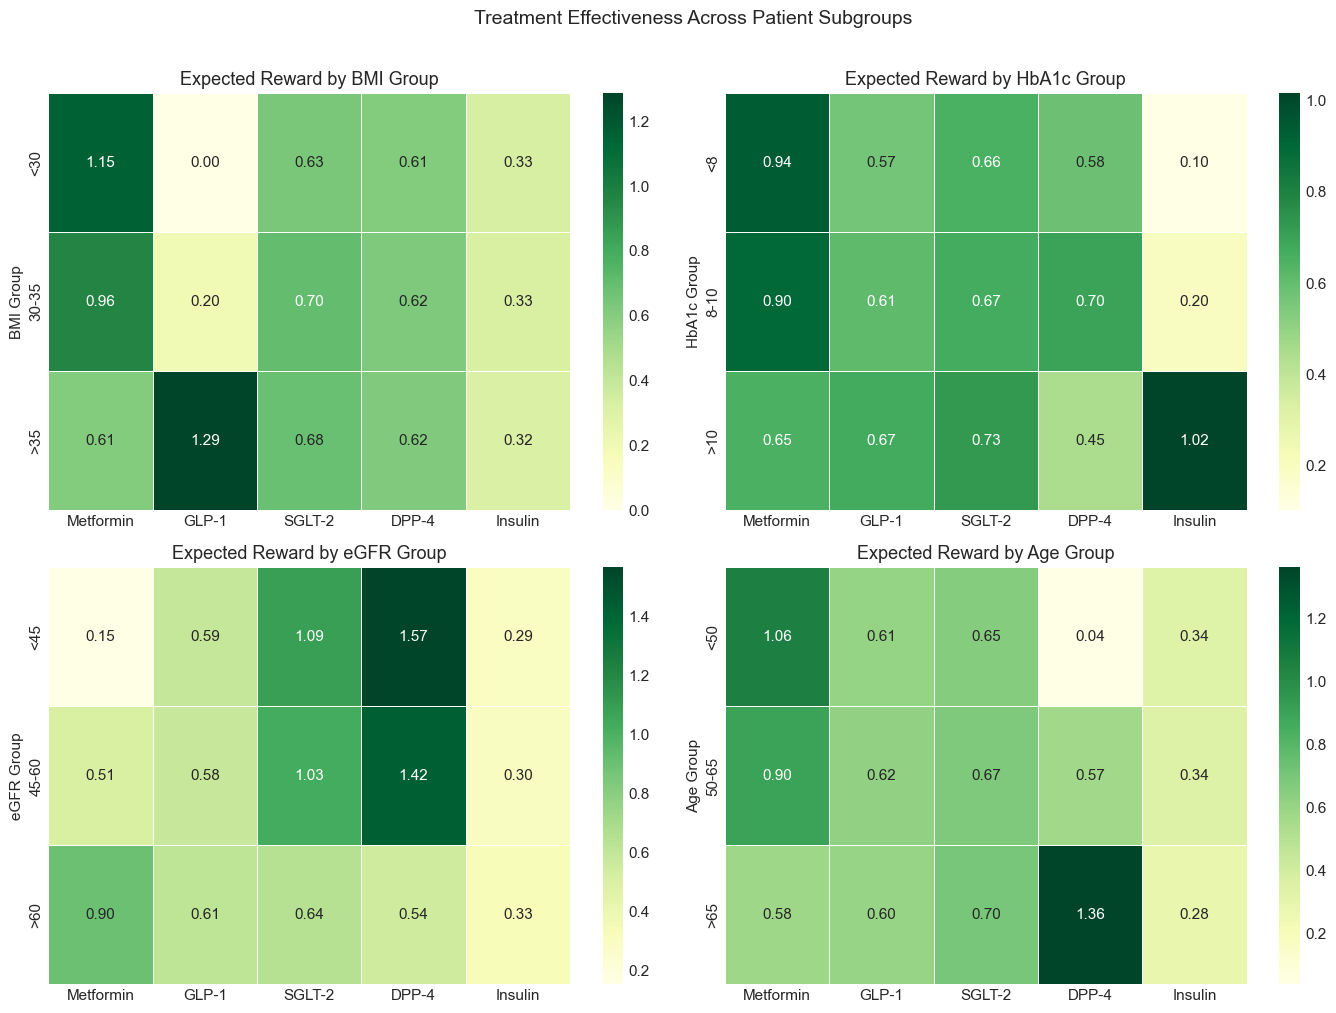

In [29]:
# Create subgroups
df['bmi_group'] = pd.cut(df['bmi'], bins=[0, 30, 35, 100], labels=['<30', '30-35', '>35'])
df['hba1c_group'] = pd.cut(df['hba1c_baseline'], bins=[0, 8, 10, 100], labels=['<8', '8-10', '>10'])
df['egfr_group'] = pd.cut(df['egfr'], bins=[0, 45, 60, 200], labels=['<45', '45-60', '>60'])
df['age_group'] = pd.cut(df['age'], bins=[0, 50, 65, 100], labels=['<50', '50-65', '>65'])

# Mean counterfactual reward by BMI group
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (group_col, group_name) in zip(axes.flatten(), [
    ('bmi_group', 'BMI Group'),
    ('hba1c_group', 'HbA1c Group'),
    ('egfr_group', 'eGFR Group'),
    ('age_group', 'Age Group'),
]):
    heatmap_data = []
    for g in df[group_col].cat.categories:
        mask = df[group_col] == g
        row = {}
        for k, t in enumerate(TREATMENTS):
            row[t] = df.loc[mask, f'reward_{k}'].mean()
        row['group'] = g
        heatmap_data.append(row)

    hm = pd.DataFrame(heatmap_data).set_index('group')[TREATMENTS]
    sns.heatmap(hm, annot=True, fmt='.2f', cmap='YlGn', ax=ax, linewidths=0.5)
    ax.set_title(f"Expected Reward by {group_name}")
    ax.set_ylabel(group_name)

plt.suptitle("Treatment Effectiveness Across Patient Subgroups", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Reward Separation Analysis (Can the Bandit Learn?)

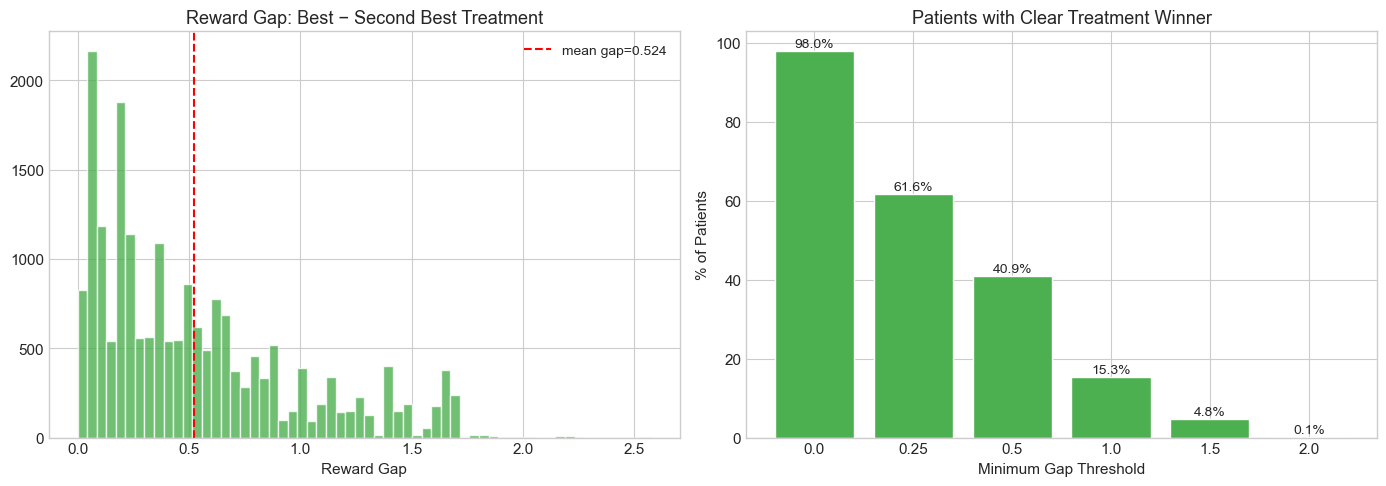

Mean reward gap (best vs 2nd best): 0.524
Patients where all treatments within 0.5: 56.8%
Patients with clear winner (gap > 1.0): 15.3%


In [30]:
# For each patient, compute gap between best and second-best treatment
cf_values = df[[f'reward_{i}' for i in range(N_TREATMENTS)]].values
sorted_cf = np.sort(cf_values, axis=1)[:, ::-1]

best_reward = sorted_cf[:, 0]
second_best = sorted_cf[:, 1]
gap = best_reward - second_best

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(gap, bins=60, color='#4CAF50', edgecolor='white', alpha=0.8)
ax1.axvline(gap.mean(), color='red', linestyle='--', label=f'mean gap={gap.mean():.3f}')
ax1.set_title("Reward Gap: Best − Second Best Treatment")
ax1.set_xlabel("Reward Gap")
ax1.legend()

# What fraction of patients have a clear winner?
thresholds = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0]
fractions = [(gap > t).mean() * 100 for t in thresholds]
ax2.bar([str(t) for t in thresholds], fractions, color='#4CAF50', edgecolor='white')
ax2.set_xlabel("Minimum Gap Threshold")
ax2.set_ylabel("% of Patients")
ax2.set_title("Patients with Clear Treatment Winner")
for i, f in enumerate(fractions):
    ax2.text(i, f + 1, f"{f:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Mean reward gap (best vs 2nd best): {gap.mean():.3f}")
print(f"Patients where all treatments within 0.5: {(gap < 0.5).mean()*100:.1f}%")
print(f"Patients with clear winner (gap > 1.0): {(gap > 1.0).mean()*100:.1f}%")

## Propensity Score Validation

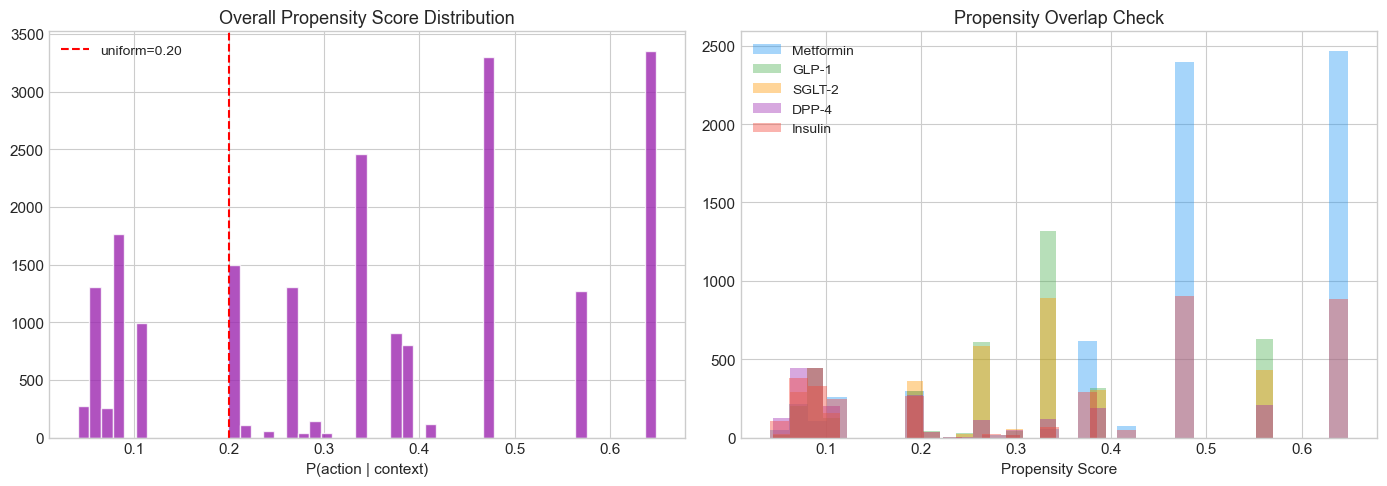

Sample propensity vectors (should sum to ~1.0):
  Patient 0: ['0.370', '0.265', '0.265', '0.050', '0.050'] → sum=1.0001
  Patient 1: ['0.064', '0.064', '0.338', '0.064', '0.471'] → sum=1.0001
  Patient 2: ['0.108', '0.570', '0.108', '0.108', '0.108'] → sum=1.0000
  Patient 3: ['0.370', '0.265', '0.265', '0.050', '0.050'] → sum=1.0001
  Patient 4: ['0.108', '0.108', '0.108', '0.570', '0.108'] → sum=1.0000

Propensity range: [0.0412, 0.6488]
Min propensity > 0: True


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Propensity distribution
ax1.hist(df['propensity'], bins=50, color='#9C27B0', edgecolor='white', alpha=0.8)
ax1.set_title("Overall Propensity Score Distribution")
ax1.set_xlabel("P(action | context)")
ax1.axvline(1/N_TREATMENTS, color='red', linestyle='--', label=f'uniform={1/N_TREATMENTS:.2f}')
ax1.legend()

# Check propensity overlap
ax2.set_title("Propensity Overlap Check")
for t in TREATMENTS:
    mask = df['action_name'] == t
    ax2.hist(df.loc[mask, 'propensity'], bins=30, alpha=0.4,
             label=t, color=TREATMENT_COLORS[t])
ax2.set_xlabel("Propensity Score")
ax2.legend()

plt.tight_layout()
plt.show()

# Verify propensities sum correctly (spot check)
import json
sample_props = df['propensity_all'].head(5).apply(json.loads)
print("Sample propensity vectors (should sum to ~1.0):")
for i, p in enumerate(sample_props):
    print(f"  Patient {i}: {[f'{x:.3f}' for x in p]} → sum={sum(p):.4f}")

print(f"\nPropensity range: [{df['propensity'].min():.4f}, {df['propensity'].max():.4f}]")
print(f"Min propensity > 0: {(df['propensity'] > 0).all()}")


## Summary — Dataset Quality Checklist

In [32]:
print("=" * 60)
print("DATASET QUALITY CHECKLIST")
print("=" * 60)

checks = {
    "No missing values": df.isnull().sum().sum() == 0,
    "All propensities > 0 (positivity)": (df['propensity'] > 0).all(),
    f"All {N_TREATMENTS} treatments present": df['action'].nunique() == N_TREATMENTS,
    "Counterfactuals available": all(f'reward_{i}' in df.columns for i in range(N_TREATMENTS)),
    "Optimal actions computed": 'optimal_action' in df.columns,
    "Regret computed": 'regret' in df.columns,
    "Meaningful reward separation": gap.mean() > 0.5,
    "Logging policy imperfect (room to improve)": df['regret'].mean() > 0.3,
    "No constant features": (df[CONTEXT_FEATURES].std() > 0).all(),
}

for check, passed in checks.items():
    status = "✅" if passed else "❌"
    print(f"  {status} {check}")

print(f"\nDataset is {'READY' if all(checks.values()) else 'NEEDS FIXES'} for bandit training.")
print("=" * 60)

DATASET QUALITY CHECKLIST
  ✅ No missing values
  ✅ All propensities > 0 (positivity)
  ✅ All 5 treatments present
  ✅ Counterfactuals available
  ✅ Optimal actions computed
  ✅ Regret computed
  ✅ Meaningful reward separation
  ✅ Logging policy imperfect (room to improve)
  ✅ No constant features

Dataset is READY for bandit training.
